In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## Loading data

In [4]:
circuits = pd.read_csv("../data/circuits.csv")
constructor_results = pd.read_csv("../data/constructor_results.csv")
constructor_standings = pd.read_csv("../data/constructor_standings.csv")
constructors = pd.read_csv("../data/constructors.csv")
driver_standings = pd.read_csv("../data/driver_standings.csv")
drivers = pd.read_csv("../data/drivers.csv")
lap_times = pd.read_csv("../data/lap_times.csv")
pit_stops = pd.read_csv("../data/pit_stops.csv")
qualifying = pd.read_csv("../data/qualifying.csv")
races = pd.read_csv("../data/races.csv")
results = pd.read_csv("../data/results.csv")
seasons = pd.read_csv("../data/seasons.csv")
sprint_results = pd.read_csv("../data/sprint_results.csv")
status = pd.read_csv("../data/status.csv")

In [5]:
#sizes of the data sets and missing data
tables = {
    "circuits": circuits,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "constructors": constructors,
    "driver_standings": driver_standings,
    "drivers": drivers,
    "lap_times": lap_times,
    "pit_stops": pit_stops,
    "qualifying": qualifying,
    "races": races,
    "results": results,
    "seasons": seasons,
    "sprint_results": sprint_results,
    "status": status
}

summary = []

for name, table in tables.items():
    summary.append({
        "table": name,
        "rows": table.shape[0],
        "columns": table.shape[1],
        "missing_values": table.isna().sum().sum()
    })

table_summary = pd.DataFrame(summary)
table_summary

,table,rows,columns,missing_values
0,circuits,77,9,0
1,constructor_results,12625,5,0
2,constructor_standings,13391,7,0
3,constructors,212,5,0
4,driver_standings,34863,7,0
5,drivers,861,9,0
6,lap_times,589081,6,0
7,pit_stops,11371,7,0
8,qualifying,10494,9,68
9,races,1125,18,0


In [6]:
for name, table in tables.items():
    print(f"\n{name.upper()}")
    print(table.columns.tolist())


CIRCUITS
['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt', 'url']

CONSTRUCTOR_RESULTS
['constructorResultsId', 'raceId', 'constructorId', 'points', 'status']

CONSTRUCTOR_STANDINGS
['constructorStandingsId', 'raceId', 'constructorId', 'points', 'position', 'positionText', 'wins']

CONSTRUCTORS
['constructorId', 'constructorRef', 'name', 'nationality', 'url']

DRIVER_STANDINGS
['driverStandingsId', 'raceId', 'driverId', 'points', 'position', 'positionText', 'wins']

DRIVERS
['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url']

LAP_TIMES
['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds']

PIT_STOPS
['raceId', 'driverId', 'stop', 'lap', 'time', 'duration', 'milliseconds']

QUALIFYING
['qualifyId', 'raceId', 'driverId', 'constructorId', 'number', 'position', 'q1', 'q2', 'q3']

RACES
['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 

## Merge into one dataset

In [7]:
df = results.copy()

df = df.merge(races, on="raceId", how="left", suffixes=("", "_race"))
df = df.merge(drivers, on="driverId", how="left", suffixes=("", "_driver"))
df = df.merge(constructors, on="constructorId", how="left", suffixes=("", "_constructor"))
df = df.merge(circuits, on="circuitId", how="left", suffixes=("", "_circuit"))
df = df.merge(status, on="statusId", how="left")

In [8]:
df.shape

(26759, 56)

In [9]:
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,url_constructor,circuitRef,name_circuit,location,country,lat,lng,alt,url_circuit,status
0,1,18,1,1,22,1,1,1,1,10.0,...,http://en.wikipedia.org/wiki/McLaren,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,Finished
1,2,18,2,2,3,5,2,2,2,8.0,...,http://en.wikipedia.org/wiki/BMW_Sauber,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,Finished
2,3,18,3,3,7,7,3,3,3,6.0,...,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,Finished
3,4,18,4,4,5,11,4,4,4,5.0,...,http://en.wikipedia.org/wiki/Renault_in_Formul...,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,Finished
4,5,18,5,1,23,3,5,5,5,4.0,...,http://en.wikipedia.org/wiki/McLaren,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.8497,144.968,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...,Finished


### Include Qualifying Data

In [10]:
new_qualifying = qualifying[[
    "raceId",
    "driverId",
    "constructorId",
    "position",
    "q1",
    "q2",
    "q3"
]].copy()

new_qualifying = new_qualifying.rename(columns={
    "position": "qualifying_position"
})

df = df.merge(
    new_qualifying,
    on=["raceId", "driverId", "constructorId"],
    how="left"
)

### Include Driver Standings Before Race

In [11]:
new_driver_standings = driver_standings[[
    "raceId",
    "driverId",
    "points",
    "position",
    "wins"
]].copy()

new_driver_standings = new_driver_standings.rename(columns={
    "points": "driver_points_after_race",
    "position": "driver_standing_after_race",
    "wins": "driver_wins_after_race"
})

df = df.merge(
    new_driver_standings,
    on=["raceId", "driverId"],
    how="left"
)

### Include Constructor Standings

In [12]:
new_constructor_standings = constructor_standings[[
    "raceId",
    "constructorId",
    "points",
    "position",
    "wins"
]].copy()

new_constructor_standings = new_constructor_standings.rename(columns={
    "points": "constructor_points_after_race",
    "position": "constructor_standing_after_race",
    "wins": "constructor_wins_after_race"
})

df = df.merge(
    new_constructor_standings,
    on=["raceId", "constructorId"],
    how="left"
)

### Inlcude Constructor Race Results

In [13]:
new_constructor_results = constructor_results[[
    "raceId",
    "constructorId",
    "points"
]].copy()

new_constructor_results = new_constructor_results.rename(columns={
    "points": "constructor_points_race"
})

df = df.merge(
    new_constructor_results,
    on=["raceId", "constructorId"],
    how="left"
)

### Include Pit Stop

- number of pit stops
- mean times
- total pit stop time for that race

In [14]:
pit_features = (
    pit_stops
    .groupby(["raceId", "driverId"])
    .agg(
        num_pit_stops=("stop", "count"),
        avg_pit_stop_ms=("milliseconds", "mean"),
        total_pit_stop_ms=("milliseconds", "sum")
    )
    .reset_index()
)

df = df.merge(
    pit_features,
    on=["raceId", "driverId"],
    how="left"
)

In [15]:
# fill missing times
df["num_pit_stops"] = df["num_pit_stops"].fillna(0)

### Include Lap times

- avg lap time
- best lap time
- std of lap times

In [16]:
lap_features = (
    lap_times
    .groupby(["raceId", "driverId"])
    .agg(
        avg_lap_ms=("milliseconds", "mean"),
        best_lap_ms=("milliseconds", "min"),
        lap_time_std_ms=("milliseconds", "std")
    )
    .reset_index()
)

df = df.merge(
    lap_features,
    on=["raceId", "driverId"],
    how="left"
)

### Include Sprint Results

In [17]:
new_sprint = sprint_results[[
    "raceId",
    "driverId",
    "constructorId",
    "grid",
    "positionOrder",
    "points"
]].copy()

new_sprint = new_sprint.rename(columns={
    "grid": "sprint_grid",
    "positionOrder": "sprint_positionOrder",
    "points": "sprint_points"
})

df = df.merge(
    new_sprint,
    on=["raceId", "driverId", "constructorId"],
    how="left"
)

#### checks

In [18]:
df.shape

(26759, 76)

In [19]:
df.head

<bound method NDFrame.head of        resultId  raceId  driverId  constructorId number  grid position  \
0             1      18         1              1     22     1        1   
1             2      18         2              2      3     5        2   
2             3      18         3              3      7     7        3   
3             4      18         4              4      5    11        4   
4             5      18         5              1     23     3        5   
...         ...     ...       ...            ...    ...   ...      ...   
26754     26760    1144       825            210     20    14       16   
26755     26761    1144       859            215     30    12       17   
26756     26762    1144       822             15     77     9       \N   
26757     26763    1144       861              3     43    20       \N   
26758     26764    1144       815              9     11    10       \N   

      positionText  positionOrder  points  ...  constructor_points_race  \
0     

In [20]:
#check 2024 Bahrain GP
races[
    (races["year"] == 2024) & (races["name"].str.contains("Bahrain", case=False, na=False))
]


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
1101,1121,2024,1,3,Bahrain Grand Prix,2024-03-02,15:00:00,https://en.wikipedia.org/wiki/2024_Bahrain_Gra...,2024-02-29,11:30:00,2024-02-29,15:00:00,2024-03-01,12:30:00,2024-03-01,16:00:00,\N,\N


In [21]:
bahrain_2024_race = races[
    (races["year"] == 2024) &
    (races["name"].str.contains("Bahrain", case=False, na=False))
]

bahrain_2024_id = bahrain_2024_race["raceId"].iloc[0]

bahrain_2024_id

np.int64(1121)

In [22]:
bahrain_2024_data = df[df["raceId"] == bahrain_2024_id].copy()

In [23]:
bahrain_2024_clean = bahrain_2024_data[[
    "raceId",
    "year",
    "round",
    "name",
    "date",
    "driverId",
    "forename",
    "surname",
    "constructorId",
    "name_constructor",
    "grid",
    "positionOrder",
    "positionText",
    "points",
    "status",
    "qualifying_position",
    "driver_points_after_race",
    "driver_standing_after_race",
    "constructor_points_after_race",
    "constructor_standing_after_race"
]].sort_values("positionOrder")

bahrain_2024_clean

,raceId,year,round,name,date,driverId,forename,surname,constructorId,name_constructor,grid,positionOrder,positionText,points,status,qualifying_position,driver_points_after_race,driver_standing_after_race,constructor_points_after_race,constructor_standing_after_race
26280,1121,2024,1,Bahrain Grand Prix,2024-03-02,830,Max,Verstappen,9,Red Bull,1,1,1,26.0,Finished,1.0,26.0,1.0,44.0,1.0
26281,1121,2024,1,Bahrain Grand Prix,2024-03-02,815,Sergio,Pérez,9,Red Bull,5,2,2,18.0,Finished,5.0,18.0,2.0,44.0,1.0
26282,1121,2024,1,Bahrain Grand Prix,2024-03-02,832,Carlos,Sainz,6,Ferrari,4,3,3,15.0,Finished,4.0,15.0,3.0,27.0,2.0
26283,1121,2024,1,Bahrain Grand Prix,2024-03-02,844,Charles,Leclerc,6,Ferrari,2,4,4,12.0,Finished,2.0,12.0,4.0,27.0,2.0
26284,1121,2024,1,Bahrain Grand Prix,2024-03-02,847,George,Russell,131,Mercedes,3,5,5,10.0,Finished,3.0,10.0,5.0,16.0,3.0
26285,1121,2024,1,Bahrain Grand Prix,2024-03-02,846,Lando,Norris,1,McLaren,7,6,6,8.0,Finished,7.0,8.0,6.0,12.0,4.0
26286,1121,2024,1,Bahrain Grand Prix,2024-03-02,1,Lewis,Hamilton,131,Mercedes,9,7,7,6.0,Finished,9.0,6.0,7.0,16.0,3.0
26287,1121,2024,1,Bahrain Grand Prix,2024-03-02,857,Oscar,Piastri,1,McLaren,8,8,8,4.0,Finished,8.0,4.0,8.0,12.0,4.0
26288,1121,2024,1,Bahrain Grand Prix,2024-03-02,4,Fernando,Alonso,117,Aston Martin,6,9,9,2.0,Finished,6.0,2.0,9.0,3.0,5.0
26289,1121,2024,1,Bahrain Grand Prix,2024-03-02,840,Lance,Stroll,117,Aston Martin,12,10,10,1.0,Finished,12.0,1.0,10.0,3.0,5.0


In [24]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/f1_full_merged_dataset.csv", index=False)

## Target variable

In [25]:
df["podium"] = (df["positionOrder"] <= 3).astype(int)

df["podium_place"] = np.where(
    df["positionOrder"] <= 3,
    df["positionOrder"],
    np.nan
)

In [26]:
df["podium"].value_counts()
df["podium"].value_counts(normalize=True)

podium
0    0.873052
1    0.126948
Name: proportion, dtype: float64

## Before Race Standings

Some variables in this dataset are only known during or after race, such as final position, points, pit stops, lap times, race status, fastest lap information, and race-level constructor points. These variables will not be used in the final pre-race prediction model because they would cause data leakage.


In [33]:
#driver 

df = df.sort_values(["driverId", "year", "round"])

df["driver_points_before_race"] = (
    df.groupby(["driverId", "year"])["driver_points_after_race"]
    .shift(1)
)

df["driver_standing_before_race"] = (
    df.groupby(["driverId", "year"])["driver_standing_after_race"]
    .shift(1)
)

df["driver_wins_before_race"] = (
    df.groupby(["driverId", "year"])["driver_wins_after_race"]
    .shift(1)
)

df["driver_standing_before_race"] = df["driver_standing_before_race"].fillna(99)

In [34]:
#contructor, corrected for 2 drivers in same race

constructor_race = (
    df[[
        "constructorId",
        "year",
        "round",
        "raceId",
        "constructor_points_after_race",
        "constructor_standing_after_race",
        "constructor_wins_after_race"
    ]]
    .drop_duplicates()
    .sort_values(["constructorId", "year", "round"])
)

constructor_race["constructor_points_before_race"] = (
    constructor_race.groupby(["constructorId", "year"])["constructor_points_after_race"]
    .shift(1)
)

constructor_race["constructor_standing_before_race"] = (
    constructor_race.groupby(["constructorId", "year"])["constructor_standing_after_race"]
    .shift(1)
)

constructor_race["constructor_wins_before_race"] = (
    constructor_race.groupby(["constructorId", "year"])["constructor_wins_after_race"]
    .shift(1)
)

constructor_race["constructor_points_before_race"] = constructor_race["constructor_points_before_race"].fillna(0)
constructor_race["constructor_wins_before_race"] = constructor_race["constructor_wins_before_race"].fillna(0)
constructor_race["constructor_standing_before_race"] = constructor_race["constructor_standing_before_race"].fillna(99)

df = df.drop(columns=[
    "constructor_points_before_race",
    "constructor_standing_before_race",
    "constructor_wins_before_race"
], errors="ignore")

df = df.merge(
    constructor_race[[
        "constructorId",
        "raceId",
        "constructor_points_before_race",
        "constructor_standing_before_race",
        "constructor_wins_before_race"
    ]],
    on=["constructorId", "raceId"],
    how="left"
)

In [35]:
#missing values
df["driver_points_before_race"] = df["driver_points_before_race"].fillna(0)
df["driver_wins_before_race"] = df["driver_wins_before_race"].fillna(0)

df["constructor_points_before_race"] = df["constructor_points_before_race"].fillna(0)
df["constructor_wins_before_race"] = df["constructor_wins_before_race"].fillna(0)

In [36]:
#check 
bahrain_2024 = df[(df["year"] == 2024) & (df["round"] == 1)].copy()

bahrain_2024[[
    "raceId",
    "year",
    "round",
    "driverId",
    "forename",
    "surname",
    "constructorId",
    "name_constructor",
    "grid",
    "positionOrder",
    "podium",
    "driver_points_before_race",
    "driver_points_after_race",
    "driver_standing_before_race",
    "driver_standing_after_race",
    "constructor_points_before_race",
    "constructor_points_after_race",
    "constructor_standing_before_race",
    "constructor_standing_after_race"
]].sort_values("positionOrder")

,raceId,year,round,driverId,forename,surname,constructorId,name_constructor,grid,positionOrder,podium,driver_points_before_race,driver_points_after_race,driver_standing_before_race,driver_standing_after_race,constructor_points_before_race,constructor_points_after_race,constructor_standing_before_race,constructor_standing_after_race
24838,1121,2024,1,830,Max,Verstappen,9,Red Bull,1,1,1,0.0,26.0,99.0,1.0,0.0,44.0,99.0,1.0
23446,1121,2024,1,815,Sergio,Pérez,9,Red Bull,5,2,1,0.0,18.0,99.0,2.0,0.0,44.0,99.0,1.0
25087,1121,2024,1,832,Carlos,Sainz,6,Ferrari,4,3,1,0.0,15.0,99.0,3.0,0.0,27.0,99.0,2.0
25948,1121,2024,1,844,Charles,Leclerc,6,Ferrari,2,4,0,0.0,12.0,99.0,4.0,0.0,27.0,99.0,2.0
26225,1121,2024,1,847,George,Russell,131,Mercedes,3,5,0,0.0,10.0,99.0,5.0,0.0,16.0,99.0,3.0
26097,1121,2024,1,846,Lando,Norris,1,McLaren,7,6,0,0.0,8.0,99.0,6.0,0.0,12.0,99.0,4.0
332,1121,2024,1,1,Lewis,Hamilton,131,Mercedes,9,7,0,0.0,6.0,99.0,7.0,0.0,16.0,99.0,3.0
26675,1121,2024,1,857,Oscar,Piastri,1,McLaren,8,8,0,0.0,4.0,99.0,8.0,0.0,12.0,99.0,4.0
1126,1121,2024,1,4,Fernando,Alonso,117,Aston Martin,6,9,0,0.0,2.0,99.0,9.0,0.0,3.0,99.0,5.0
25558,1121,2024,1,840,Lance,Stroll,117,Aston Martin,12,10,0,0.0,1.0,99.0,10.0,0.0,3.0,99.0,5.0


Bahrain 2024 is the first race of the season, all before-race points are 0 and before-race standings are filled with 99 because no season andings existed before Round 1. The after-race columns reflect the actual results from the race, so they are not used as predictors.

## EDA

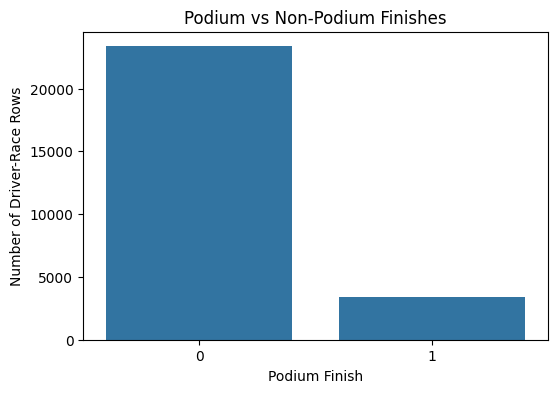

In [37]:
#podium vs non-podium distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="podium")

plt.title("Podium vs Non-Podium Finishes")
plt.xlabel("Podium Finish")
plt.ylabel("Number of Driver-Race Rows")
plt.show()


Analysis

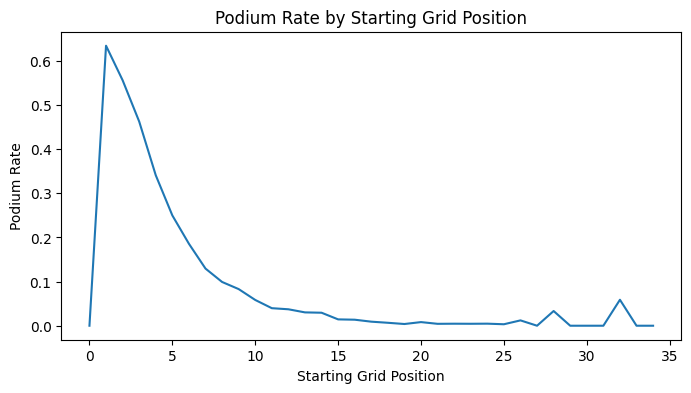

In [38]:
#podium rate by starting grid position
grid_podium = df.groupby("grid")["podium"].mean().reset_index()

plt.figure(figsize=(8,4))

sns.lineplot(data=grid_podium, x="grid", y="podium")

plt.title("Podium Rate by Starting Grid Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Podium Rate")
plt.show()

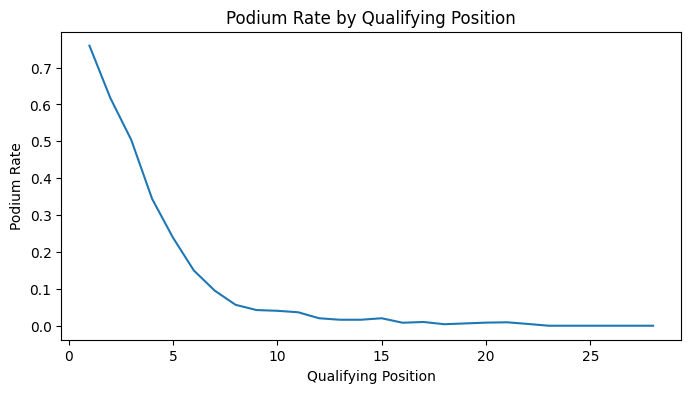

In [39]:
#Podium rate by qualifying position
qual_podium = df.groupby("qualifying_position")["podium"].mean().reset_index()

plt.figure(figsize=(8,4))

sns.lineplot(data=qual_podium, x="qualifying_position", y="podium")

plt.title("Podium Rate by Qualifying Position")
plt.xlabel("Qualifying Position")
plt.ylabel("Podium Rate")
plt.show()

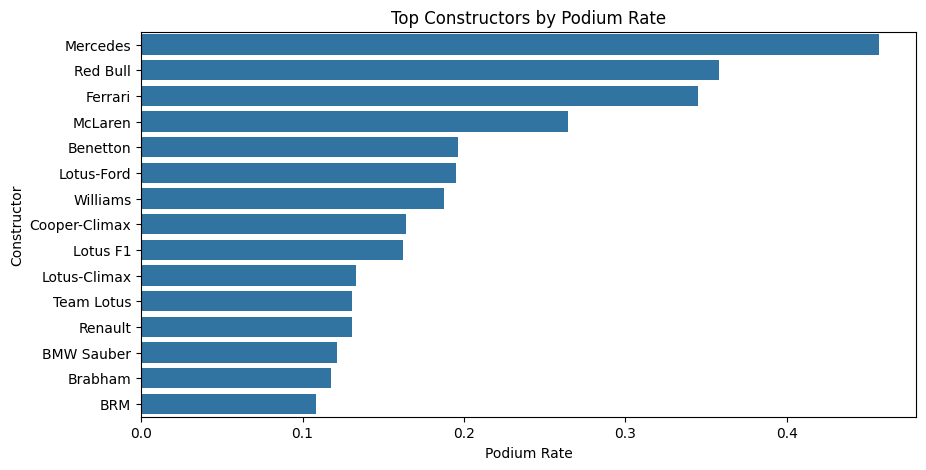

In [40]:
#Top constructors by podium rate
constructor_podium = (
    df.groupby("name_constructor")["podium"]
    .agg(["count", "mean"])
    .reset_index()
)

constructor_podium = constructor_podium[constructor_podium["count"] >= 100]

constructor_podium = constructor_podium.sort_values("mean", ascending=False).head(15)

plt.figure(figsize=(10,5))

sns.barplot(data=constructor_podium, x="mean", y="name_constructor")

plt.title("Top Constructors by Podium Rate")
plt.xlabel("Podium Rate")
plt.ylabel("Constructor")
plt.show()

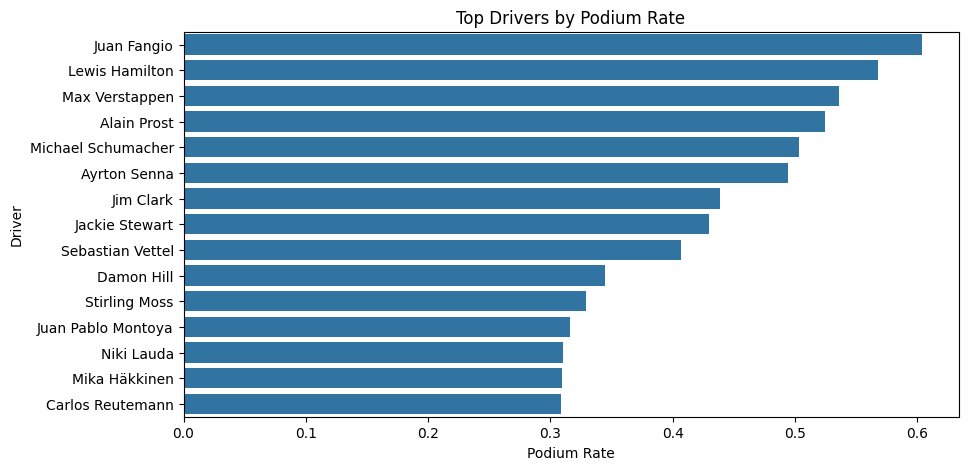

In [41]:
#Top drivers by podium rate
df["driver_name"] = df["forename"] + " " + df["surname"]

driver_podium = (
    df.groupby("driver_name")["podium"]
    .agg(["count", "mean"])
    .reset_index()
)

driver_podium = driver_podium[driver_podium["count"] >= 50]

driver_podium = driver_podium.sort_values("mean", ascending=False).head(15)

plt.figure(figsize=(10,5))

sns.barplot(data=driver_podium, x="mean", y="driver_name")

plt.title("Top Drivers by Podium Rate")
plt.xlabel("Podium Rate")
plt.ylabel("Driver")
plt.show()


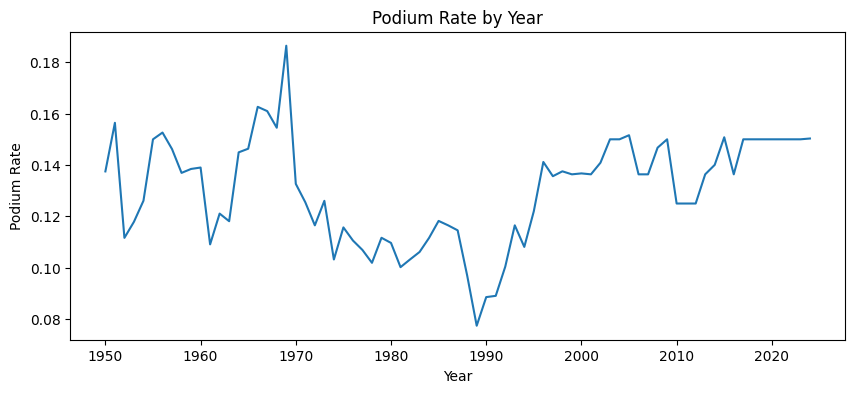

In [42]:
#Podium rate by year
year_podium = df.groupby("year")["podium"].mean().reset_index()

plt.figure(figsize=(10,4))

sns.lineplot(data=year_podium, x="year", y="podium")

plt.title("Podium Rate by Year")
plt.xlabel("Year")
plt.ylabel("Podium Rate")
plt.show()

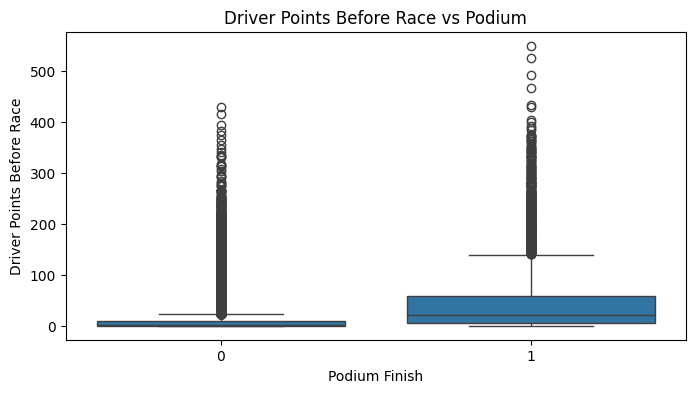

In [43]:
#Points before race vs podium
plt.figure(figsize=(8,4))

sns.boxplot(data=df, x="podium", y="driver_points_before_race")

plt.title("Driver Points Before Race vs Podium")
plt.xlabel("Podium Finish")
plt.ylabel("Driver Points Before Race")
plt.show()

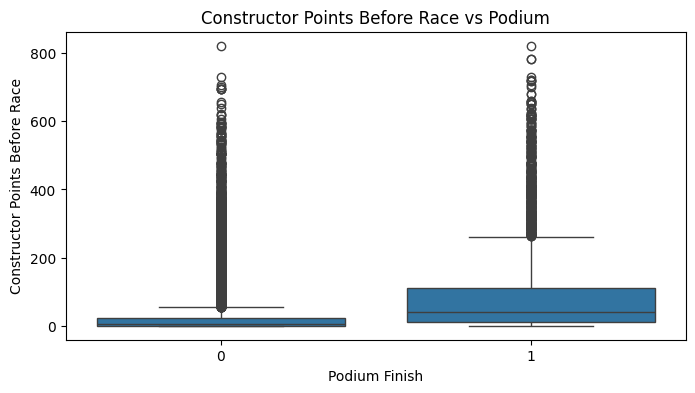

In [44]:
#Constructor points before race vs podium
plt.figure(figsize=(8,4))

sns.boxplot(data=df, x="podium", y="constructor_points_before_race")

plt.title("Constructor Points Before Race vs Podium")
plt.xlabel("Podium Finish")
plt.ylabel("Constructor Points Before Race")
plt.show()

In [45]:
#Missing values check
missing = df.isna().sum().sort_values(ascending=False)

missing[missing > 0].head(20)

sprint_grid                        26399
sprint_points                      26399
sprint_positionOrder               26399
podium_place                       23362
avg_pit_stop_ms                    21184
total_pit_stop_ms                  21184
q3                                 16321
q2                                 16297
qualifying_position                16275
q1                                 16275
lap_time_std_ms                    15833
best_lap_ms                        15718
avg_lap_ms                         15718
constructor_standing_after_race     1867
constructor_wins_after_race         1867
constructor_points_after_race       1867
constructor_points_race             1611
driver_wins_after_race               469
driver_points_after_race             469
driver_standing_after_race           469
dtype: int64

In [46]:
df.to_csv("../data/processed/f1_full_merged_dataset.csv", index=False)